In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
import joblib

with open('train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    return results

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_results = evaluate_model("Logistic Regression", lr, X_test, y_test)


Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1593
           1       0.38      0.64      0.47       407

    accuracy                           0.71      2000
   macro avg       0.63      0.69      0.64      2000
weighted avg       0.78      0.71      0.73      2000



In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_results = evaluate_model("Decision Tree", dt, X_test, y_test)


Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1593
           1       0.45      0.56      0.50       407

    accuracy                           0.77      2000
   macro avg       0.67      0.69      0.68      2000
weighted avg       0.79      0.77      0.78      2000



In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_results = evaluate_model("Decision Tree", dt, X_test, y_test)


Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1593
           1       0.45      0.56      0.50       407

    accuracy                           0.77      2000
   macro avg       0.67      0.69      0.68      2000
weighted avg       0.79      0.77      0.78      2000



In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_results = evaluate_model("Random Forest", rf, X_test, y_test)


Random Forest
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.60      0.59      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [13]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_results = evaluate_model("Gradient Boosting", gb, X_test, y_test)


Gradient Boosting
              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.70      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7095     0.3754  0.6437  0.4742   0.7525
Decision Tree          0.7735     0.4540  0.5577  0.5006   0.6932
Random Forest          0.8365     0.6000  0.5897  0.5948   0.8448
Gradient Boosting      0.8200     0.5449  0.7002  0.6129   0.8607


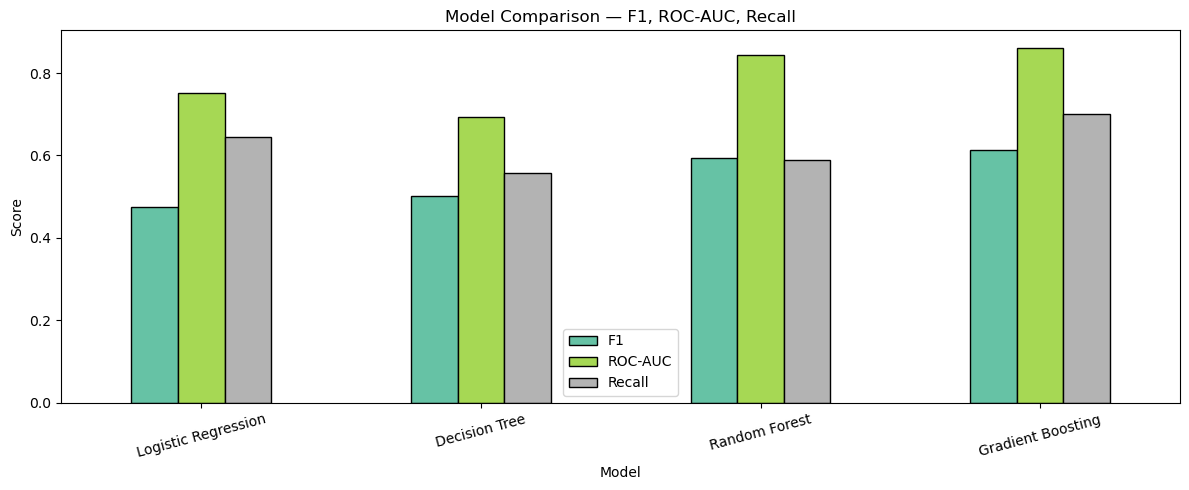

In [14]:
results_df = pd.DataFrame([lr_results, dt_results, rf_results, gb_results])
results_df.set_index('Model', inplace=True)
print(results_df)

results_df[['F1', 'ROC-AUC', 'Recall']].plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — F1, ROC-AUC, Recall')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [15]:
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(gb, 'gradient_boosting_model.pkl')
print("Models saved.")

Models saved.


In [16]:
print(results_df)

                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7095     0.3754  0.6437  0.4742   0.7525
Decision Tree          0.7735     0.4540  0.5577  0.5006   0.6932
Random Forest          0.8365     0.6000  0.5897  0.5948   0.8448
Gradient Boosting      0.8200     0.5449  0.7002  0.6129   0.8607
